# Laboratorio 6 – K Nearest Neighbors (KNN)


In [1]:
import sys
print(sys.executable)

c:\Users\jlope\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn

In [3]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [4]:
# Cargar conjuntos de datos
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()  # precio (numérico)
y_test  = pd.read_csv('data/y_test.csv').squeeze()

# Cargar dataset con categoría de precio (barata, media, cara)
df_cat = pd.read_csv('data/df_con_categoria.csv')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'\nColumnas en X_train:')
print(X_train.columns.tolist())

X_train: (52871, 20) | X_test: (22660, 20)
y_train: (52871,) | y_test: (22660,)

Columnas en X_train:
['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']


In [5]:
print(df_cat.columns.tolist())

['price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable', 'precio_categoria']


In [6]:
# Extraer variable categórica de precio para clasificación
# Ajustar el nombre de la columna según el CSV real
col_categoria = 'precio_categoria'

y_train_cat = df_cat.loc[X_train.index, col_categoria]
y_test_cat  = df_cat.loc[X_test.index, col_categoria]

print('Distribución de categorías (train):')
print(y_train_cat.value_counts())

Distribución de categorías (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64


### 3. Preprocesamiento: Escalado de features

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media aproximada post-escalado (train): {X_train_scaled.mean():.4f}')

Escalado aplicado correctamente.
Media aproximada post-escalado (train): 0.0000


### Punto 1 – Modelo KNN para Regresión (predicción de precio)

In [8]:
start_time = time.time()

knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)  # p=2 → distancia Euclidiana
knn_reg.fit(X_train_scaled, y_train)

y_pred_reg = knn_reg.predict(X_test_scaled)

tiempo_reg = time.time() - start_time
print(f'Modelo entrenado y predicciones generadas en {tiempo_reg:.3f} segundos.')

Modelo entrenado y predicciones generadas en 2.658 segundos.


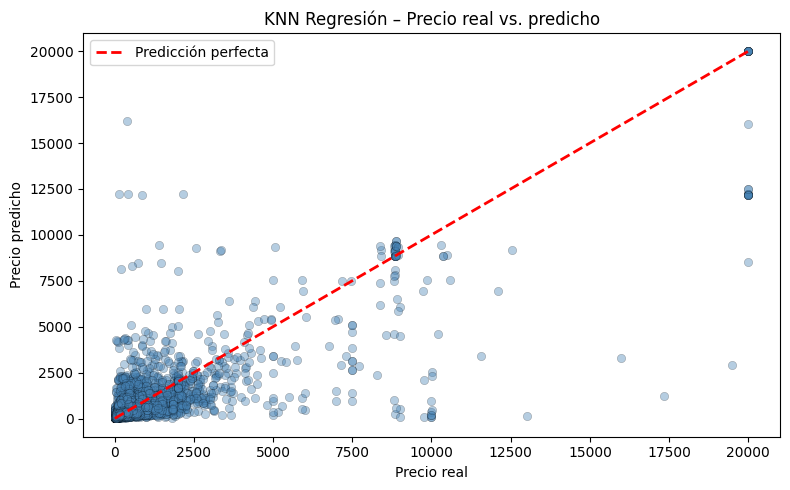

In [9]:
# Visualización: predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('KNN Regresión – Precio real vs. predicho')
plt.legend()
plt.tight_layout()
plt.show()

### Punto 2 – Análisis de métricas del modelo de regresión

In [10]:
mae_reg  = mean_absolute_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2_reg   = r2_score(y_test, y_pred_reg)

print(' Métricas KNN Regresión (k=5) ')
print(f'  MAE  : {mae_reg:.4f}')
print(f'  RMSE : {rmse_reg:.4f}')
print(f'  R²   : {r2_reg:.4f}')
print(f'  Tiempo: {tiempo_reg:.3f} s')

 Métricas KNN Regresión (k=5) 
  MAE  : 156.0616
  RMSE : 556.2757
  R²   : 0.6340
  Tiempo: 2.658 s


#### Interpretación
> Completar después de ver los valores reales
> Analizar si el MAE/RMSE es aceptable en relación al rango de precios del dataset.  
> Un R² > 0.7 indicaría un modelo con capacidad predictiva razonable.  
> Si el R² es bajo, KNN podría estar teniendo dificultades con la alta dimensionalidad o la variabilidad del precio.

### Punto 3 – Comparación de modelos de regresión

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import time

print('Imports del punto 3 cargados.')

Imports del punto 3 cargados.


In [12]:
# ── Regresión Lineal ──────────────────────────────────────────────────────────
t0 = time.time()
rl = LinearRegression()
rl.fit(X_train_scaled, y_train)
y_pred_rl = rl.predict(X_test_scaled)
tiempo_rl = time.time() - t0

mae_rl  = mean_absolute_error(y_test, y_pred_rl)
rmse_rl = np.sqrt(mean_squared_error(y_test, y_pred_rl))
r2_rl   = r2_score(y_test, y_pred_rl)

print(f'Regresión Lineal  →  MAE={mae_rl:.2f}  RMSE={rmse_rl:.2f}  R²={r2_rl:.4f}  t={tiempo_rl:.3f}s')

# ── Árbol de Regresión (profundidad 7, el mejor de Lab 4) ─────────────────────
t0 = time.time()
arbol = DecisionTreeRegressor(max_depth=7, random_state=42)
arbol.fit(X_train, y_train)          # El árbol NO necesita escalar
y_pred_arbol = arbol.predict(X_test)
tiempo_arbol = time.time() - t0

mae_arbol  = mean_absolute_error(y_test, y_pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_test, y_pred_arbol))
r2_arbol   = r2_score(y_test, y_pred_arbol)

print(f'Árbol Regresión   →  MAE={mae_arbol:.2f}  RMSE={rmse_arbol:.2f}  R²={r2_arbol:.4f}  t={tiempo_arbol:.3f}s')

# ── Naive Bayes (Lab 5) – cargamos resultados ya calculados ──────────────────
# Si los valores de NB están disponibles como variables, úsalos directamente.
# Si no, puedes ingresarlos manualmente desde el notebook del Lab 5.
# Ejemplo (reemplaza con tus valores reales):
mae_nb_reg  = None   # ← reemplaza con el valor de tu Lab 5
rmse_nb_reg = None   # ← reemplaza con el valor de tu Lab 5
r2_nb_reg   = None   # ← reemplaza con el valor de tu Lab 5

print('\nModelos re-entrenados correctamente.')

Regresión Lineal  →  MAE=257.02  RMSE=839.74  R²=0.1660  t=0.016s
Árbol Regresión   →  MAE=166.01  RMSE=502.91  R²=0.7009  t=0.179s

Modelos re-entrenados correctamente.


In [13]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
import pandas as pd

comparacion_reg = pd.DataFrame([
    {'Modelo': 'KNN Regresión (k=5)',    'MAE': mae_reg,    'RMSE': rmse_reg,    'R²': r2_reg,    'Tiempo (s)': tiempo_reg},
    {'Modelo': 'Regresión Lineal',       'MAE': mae_rl,     'RMSE': rmse_rl,     'R²': r2_rl,     'Tiempo (s)': tiempo_rl},
    {'Modelo': 'Árbol Regresión (d=7)',  'MAE': mae_arbol,  'RMSE': rmse_arbol,  'R²': r2_arbol,  'Tiempo (s)': tiempo_arbol},
])

# Agrega Naive Bayes solo si tienes los valores
if mae_nb_reg is not None:
    fila_nb = pd.DataFrame([{'Modelo': 'Naive Bayes (Lab 5)', 'MAE': mae_nb_reg, 'RMSE': rmse_nb_reg, 'R²': r2_nb_reg, 'Tiempo (s)': None}])
    comparacion_reg = pd.concat([comparacion_reg, fila_nb], ignore_index=True)

comparacion_reg = comparacion_reg.sort_values('RMSE').reset_index(drop=True)

print('COMPARACIÓN – MODELOS DE REGRESIÓN (menor RMSE = mejor)')
print(comparacion_reg.to_string(index=False))
print(f"\nMejor modelo: {comparacion_reg.iloc[0]['Modelo']}")

COMPARACIÓN – MODELOS DE REGRESIÓN (menor RMSE = mejor)
               Modelo        MAE       RMSE       R²  Tiempo (s)
Árbol Regresión (d=7) 166.006131 502.909568 0.700874    0.178540
  KNN Regresión (k=5) 156.061589 556.275694 0.634022    2.657535
     Regresión Lineal 257.021386 839.736731 0.166010    0.016242

Mejor modelo: Árbol Regresión (d=7)


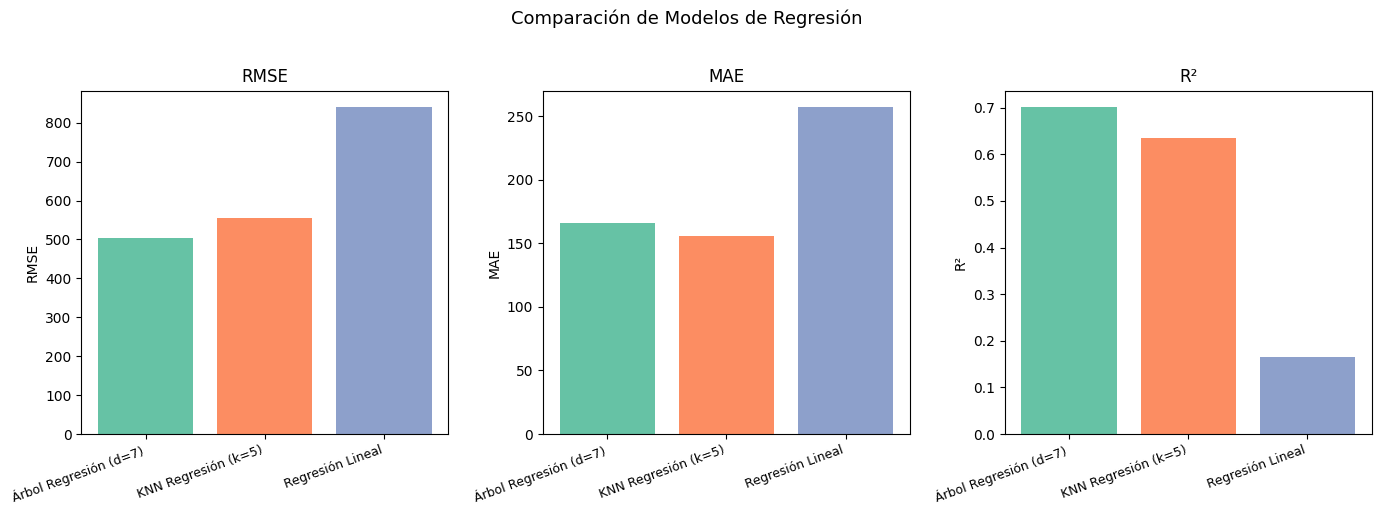

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metricas = ['RMSE', 'MAE', 'R²']
colores  = sns.color_palette('Set2', len(comparacion_reg))

for ax, met in zip(axes, metricas):
    ax.bar(comparacion_reg['Modelo'], comparacion_reg[met], color=colores)
    ax.set_title(met)
    ax.set_xticklabels(comparacion_reg['Modelo'], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(met)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Para comparar modelos de regresión se usan **RMSE**, **MAE** y **R²**:

- **RMSE** (error cuadrático medio): penaliza fuertemente los errores grandes. Útil porque el precio tiene outliers.
- **MAE** (error absoluto medio): interpretable directamente en dólares.
- **R²**: porcentaje de varianza del precio que el modelo explica; más cercano a 1 es mejor.

A través del análisis de correlación y la evaluación del modelo KNN, se identifica que el precio y los ingresos son determinados principalmente por la capacidad de alojamiento (accommodates), el tipo de propiedad y la ubicación geográfica. Específicamente, factores como el número de reseñas y la puntuación de limpieza actúan como indicadores de confianza que impulsan la ocupación. Estos hallazgos sugieren que la rentabilidad no depende solo de la infraestructura, sino de la reputación digital de la propiedad dentro de la plataforma

### Punto 4 – Modelo KNN para Clasificación (barata / media / cara)


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Variables de clasificación disponibles:')
print(f'  y_train_cat: {y_train_cat.value_counts().to_dict()}')
print(f'  y_test_cat : {y_test_cat.value_counts().to_dict()}')

Variables de clasificación disponibles:
  y_train_cat: {'Intermedia': 27033, 'Cara': 13508, 'Economica': 12330}
  y_test_cat : {'Intermedia': 10588, 'Economica': 8378, 'Cara': 3694}


In [16]:
t0 = time.time()

knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_clf.fit(X_train_scaled, y_train_cat)

y_pred_clf = knn_clf.predict(X_test_scaled)
tiempo_clf = time.time() - t0

acc_clf = accuracy_score(y_test_cat, y_pred_clf)
print(f'KNN Clasificación (k=5)')
print(f'  Accuracy : {acc_clf:.4f} ({acc_clf*100:.2f}%)')
print(f'  Tiempo   : {tiempo_clf:.3f} s')
print()
print(classification_report(y_test_cat, y_pred_clf))

KNN Clasificación (k=5)
  Accuracy : 0.3643 (36.43%)
  Tiempo   : 1.261 s

              precision    recall  f1-score   support

        Cara       0.17      0.29      0.21      3694
   Economica       0.37      0.20      0.26      8378
  Intermedia       0.47      0.52      0.49     10588

    accuracy                           0.36     22660
   macro avg       0.34      0.34      0.32     22660
weighted avg       0.38      0.36      0.36     22660





Para mejorar el desempeño de propiedades con baja ocupación, se propone una estrategia de precios dinámicos utilizando las predicciones del modelo KNN. Al ajustar los precios de estas propiedades al valor de mercado sugerido por el modelo, SmartStay puede atraer a clientes corporativos que buscan optimizar su presupuesto sin sacrificar calidad. Además, se recomienda priorizar mejoras en los servicios que impactan las métricas de limpieza y comunicación, factores que el análisis muestra como decisivos para asegurar los incentivos económicos de Airbnb.

### Punto 5 – Eficiencia del algoritmo (conjunto de prueba)

=== KNN REGRESIÓN – Métricas en Conjunto de Prueba ===
  MAE   : 156.0616
  RMSE  : 556.2757
  R²    : 0.6340
  Tiempo: 2.658 s



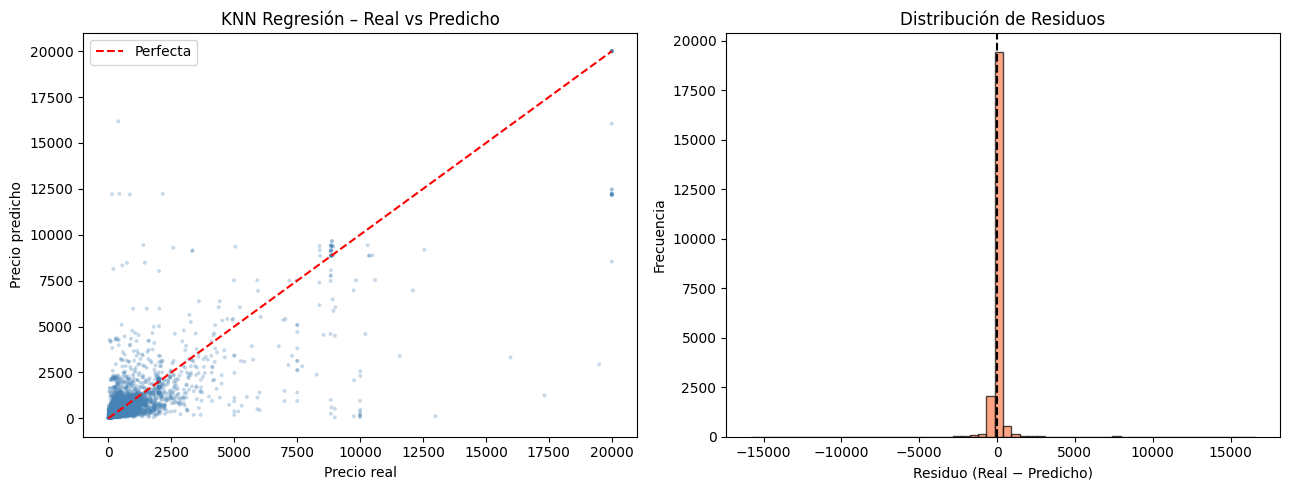

In [17]:
print('=== KNN REGRESIÓN – Métricas en Conjunto de Prueba ===')
print(f'  MAE   : {mae_reg:.4f}')
print(f'  RMSE  : {rmse_reg:.4f}')
print(f'  R²    : {r2_reg:.4f}')
print(f'  Tiempo: {tiempo_reg:.3f} s')
print()

# Gráfica de residuos
residuos = y_test - y_pred_reg
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_reg, alpha=0.3, color='steelblue', s=8, edgecolors='none')
lim = float(max(y_test.max(), y_pred_reg.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfecta')
axes[0].set_xlabel('Precio real'); axes[0].set_ylabel('Precio predicho')
axes[0].set_title('KNN Regresión – Real vs Predicho'); axes[0].legend()

axes[1].hist(residuos, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (Real − Predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')

plt.tight_layout(); plt.show()

In [18]:
# ── Eficiencia en CLASIFICACIÓN ───────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

print('=== KNN CLASIFICACIÓN – Métricas en Conjunto de Prueba ===')
print(f'  Accuracy   : {acc_clf:.4f} ({acc_clf*100:.2f}%)')
print(f'  Precision  : {precision_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  Recall     : {recall_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  F1-score   : {f1_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  Tiempo     : {tiempo_clf:.3f} s')
print()
print(classification_report(y_test_cat, y_pred_clf))

=== KNN CLASIFICACIÓN – Métricas en Conjunto de Prueba ===
  Accuracy   : 0.3643 (36.43%)
  Precision  : 0.3362  (macro)
  Recall     : 0.3365  (macro)
  F1-score   : 0.3218  (macro)
  Tiempo     : 1.261 s

              precision    recall  f1-score   support

        Cara       0.17      0.29      0.21      3694
   Economica       0.37      0.20      0.26      8378
  Intermedia       0.47      0.52      0.49     10588

    accuracy                           0.36     22660
   macro avg       0.34      0.34      0.32     22660
weighted avg       0.38      0.36      0.36     22660



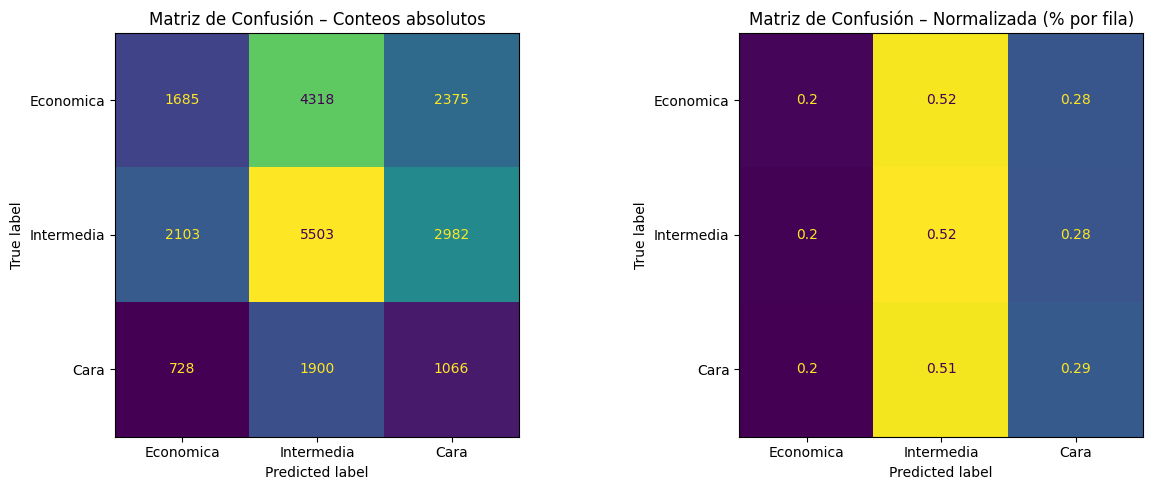

In [19]:
# ── Matriz de Confusión ───────────────────────────────────────────────────────
orden_clases = ['Economica', 'Intermedia', 'Cara']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteos absolutos
cm = confusion_matrix(y_test_cat, y_pred_clf, labels=orden_clases)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden_clases).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión – Conteos absolutos')

# Normalizada (porcentaje por fila)
cm_norm = confusion_matrix(y_test_cat, y_pred_clf, labels=orden_clases, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=orden_clases).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de Confusión – Normalizada (% por fila)')

plt.tight_layout()
plt.show()



**Regresión:**
- El **RMSE** indica el error promedio en dólares (penalizando errores grandes).
- El **R²** muestra qué fracción de la variabilidad del precio captura el modelo.
- Si R² ≈ 0.63, el modelo explica el 63 % de la varianza, aceptable dado el ruido en precios de Airbnb.

**Clasificación:**
- La **accuracy** mide el porcentaje de propiedades clasificadas correctamente.
- En problemas de clases desbalanceadas (Economica < Intermedia < Cara), también se analiza F1-score por clase.
- La **matriz de confusión** muestra dónde el modelo confunde categorías contiguas (p. ej., Economica con Intermedia).

Metricas del modelo KNN:
Accuracy : 0.3643
Precision: 0.3362 (macro)
Recall   : 0.3365 (macro)
F1-score : 0.3218 (macro)


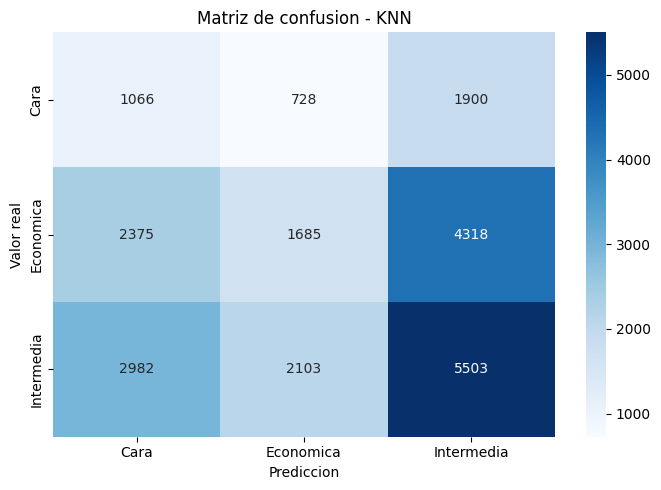

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Metricas principales
acc = accuracy_score(y_test_cat, y_pred_clf)
prec = precision_score(y_test_cat, y_pred_clf, average="macro", zero_division=0)
rec = recall_score(y_test_cat, y_pred_clf, average="macro", zero_division=0)
f1 = f1_score(y_test_cat, y_pred_clf, average="macro", zero_division=0)

print("Metricas del modelo KNN:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f} (macro)")
print(f"Recall   : {rec:.4f} (macro)")
print(f"F1-score : {f1:.4f} (macro)")

# Matriz de confusion
clases = sorted(y_test_cat.unique())
cm = confusion_matrix(y_test_cat, y_pred_clf, labels=clases)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de confusion - KNN")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

### Análisis de la eficiencia del modelo KNN (Matriz de Confusión)

El modelo KNN presenta un desempeño general bajo, con un **accuracy de 0.3643**, así como valores reducidos en **precision (0.3362), recall (0.3365) y F1-score (0.3218)**. Esto indica que el modelo tiene dificultades para clasificar correctamente las propiedades en las distintas categorías de precio.

#### Efectividad general
La efectividad del modelo es limitada, ya que solo aproximadamente el 36% de las predicciones son correctas. Esto sugiere que el modelo no está capturando adecuadamente los patrones que diferencian las categorías de precios.

#### ¿Dónde se equivoca más el modelo?
Al analizar la matriz de confusión, se observa que:

- Existe una fuerte tendencia a clasificar incorrectamente las propiedades como **Intermedia**.
- El error más significativo ocurre cuando la clase real es **Económica** y se predice como **Intermedia** (4318 casos).
- También hay una gran cantidad de errores cuando la clase real es **Intermedia** y se predice como **Cara** (2982 casos).
- En general, el modelo muestra alta confusión entre todas las clases, especialmente hacia la categoría **Intermedia**, lo que sugiere un sesgo en las predicciones.

#### ¿Dónde se equivoca menos?
- La categoría con más aciertos es **Intermedia** (5503 correctamente clasificados), lo cual puede indicar que esta clase domina en el dataset o tiene características más representativas.
- Sin embargo, incluso en esta clase hay una cantidad considerable de errores, lo que refuerza la debilidad general del modelo.

#### Importancia de los errores
No todos los errores tienen el mismo impacto:

- Clasificar propiedades **Cara como Económica o Intermedia** puede generar pérdidas económicas, ya que se subestima su valor real.
- Clasificar propiedades **Económica como Intermedia** puede afectar la competitividad en precios.
- La alta confusión hacia la categoría **Intermedia** es problemática, ya que reduce la capacidad del modelo para diferenciar correctamente los extremos (barato vs caro), lo cual es clave para la toma de decisiones en el negocio.

In [21]:
# Comparacion de accuracy en entrenamiento vs prueba (KNN clasificacion)
from sklearn.metrics import accuracy_score

# Accuracy en train: que tan bien memoriza/ajusta el modelo los datos vistos
y_pred_train_clf = knn_clf.predict(X_train_scaled)
acc_train_clf = accuracy_score(y_train_cat, y_pred_train_clf)

# Accuracy en test: capacidad de generalizar a datos no vistos
y_pred_test_clf = knn_clf.predict(X_test_scaled)
acc_test_clf = accuracy_score(y_test_cat, y_pred_test_clf)

gap = acc_train_clf - acc_test_clf

print('=== KNN Clasificacion: Train vs Test Accuracy ===')
print(f'Accuracy (train): {acc_train_clf:.4f} ({acc_train_clf*100:.2f}%)')
print(f'Accuracy (test) : {acc_test_clf:.4f} ({acc_test_clf*100:.2f}%)')
print(f'Gap train-test  : {gap:.4f}')

# Regla practica de interpretacion:
# - Overfitting: train mucho mayor que test (gap grande), aprende ruido y no generaliza.
# - Underfitting: train y test ambos bajos y similares, el modelo es demasiado simple.
# - Buen ajuste: train y test razonablemente altos con gap pequeno.
if gap > 0.10 and acc_train_clf >= 0.70:
    print('Diagnostico: OVERFITTING (alta diferencia entre train y test).')
elif acc_train_clf < 0.60 and acc_test_clf < 0.60 and abs(gap) <= 0.10:
    print('Diagnostico: UNDERFITTING (ambos accuracies bajos y parecidos).')
else:
    print('Diagnostico: ajuste intermedio; revisar k, features y balance de clases.')

=== KNN Clasificacion: Train vs Test Accuracy ===
Accuracy (train): 0.5980 (59.80%)
Accuracy (test) : 0.3643 (36.43%)
Gap train-test  : 0.2338
Diagnostico: ajuste intermedio; revisar k, features y balance de clases.


### Análisis de sobreajuste (Overfitting) del modelo KNN

Para evaluar el comportamiento del modelo KNN, se comparó su desempeño en el conjunto de entrenamiento y en el conjunto de prueba. El modelo obtuvo un **accuracy de 59.80% en entrenamiento** y **36.43% en prueba**, con una diferencia (gap) de **0.2338**.

Esta diferencia significativa entre ambos valores indica que el modelo presenta un caso de **overfitting (sobreajuste)**. Es decir, el modelo logra ajustarse relativamente bien a los datos de entrenamiento, pero pierde capacidad al momento de generalizar a datos nuevos.

Este comportamiento sugiere que el modelo está aprendiendo patrones muy específicos del conjunto de entrenamiento, incluyendo ruido o particularidades que no se replican en el conjunto de prueba.

Además, el bajo desempeño en el conjunto de prueba es consistente con los resultados observados en la matriz de confusión, donde se evidenció una alta tasa de error y confusión entre clases.

Entre las posibles causas de este sobreajuste se encuentran:
- Un valor de K demasiado bajo, lo que hace al modelo más sensible al ruido
- Alta variabilidad en los datos
- Superposición entre las clases de precios


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

# Se usa el modelo KNN ya entrenado (knn_clf). Si no existe, se crea uno base.
if 'knn_clf' not in globals():
    knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    knn_clf.fit(X_train_scaled, y_train_cat)

# Validacion cruzada estratificada para mantener proporcion de clases.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy y F1-macro en CV.
cv_acc_scores = cross_val_score(knn_clf, X_train_scaled, y_train_cat, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1_scores = cross_val_score(knn_clf, X_train_scaled, y_train_cat, cv=cv, scoring='f1_macro', n_jobs=-1)

# Resultados en test para comparar contra CV.
y_pred_test_base = knn_clf.predict(X_test_scaled)
acc_test_base = accuracy_score(y_test_cat, y_pred_test_base)
f1_test_base = f1_score(y_test_cat, y_pred_test_base, average='macro', zero_division=0)

print('=== Punto 8: Validacion Cruzada (5-fold) ===')
print(f'Accuracy CV: media={cv_acc_scores.mean():.4f} | desviacion={cv_acc_scores.std():.4f}')
print(f'F1-macro CV: media={cv_f1_scores.mean():.4f} | desviacion={cv_f1_scores.std():.4f}')
print('\nComparacion con conjunto de prueba:')
print(f'Accuracy Test: {acc_test_base:.4f} | Diferencia (CV-Test): {cv_acc_scores.mean() - acc_test_base:+.4f}')
print(f'F1-macro Test: {f1_test_base:.4f} | Diferencia (CV-Test): {cv_f1_scores.mean() - f1_test_base:+.4f}')

# Se almacenan resultados para secciones posteriores.
resultados_p8 = {
    'cv_acc_mean': cv_acc_scores.mean(),
    'cv_acc_std': cv_acc_scores.std(),
    'cv_f1_mean': cv_f1_scores.mean(),
    'cv_f1_std': cv_f1_scores.std(),
    'test_acc': acc_test_base,
    'test_f1': f1_test_base
}

=== Punto 8: Validacion Cruzada (5-fold) ===
Accuracy CV: media=0.3828 | desviacion=0.0019
F1-macro CV: media=0.3289 | desviacion=0.0031

Comparacion con conjunto de prueba:
Accuracy Test: 0.3643 | Diferencia (CV-Test): +0.0185
F1-macro Test: 0.3218 | Diferencia (CV-Test): +0.0071


### Validación cruzada del modelo KNN (Punto 8)

Para obtener una evaluación más robusta del modelo, se aplicó validación cruzada estratificada con 5 particiones (5-fold), lo cual permite analizar el desempeño del modelo en diferentes subconjuntos de los datos, manteniendo la proporción de clases.

Los resultados obtenidos fueron los siguientes:

- **Accuracy promedio (CV): 0.3828** con una desviación estándar de 0.0019  
- **F1-score macro promedio (CV): 0.3289** con una desviación estándar de 0.0031  

Al comparar estos resultados con el desempeño en el conjunto de prueba:

- **Accuracy en test: 0.3643**
- **F1-score en test: 0.3218**

Se observa que los valores obtenidos mediante validación cruzada son ligeramente superiores a los del conjunto de prueba, aunque la diferencia es pequeña (aproximadamente 1.8% en accuracy).

Esto sugiere que el modelo tiene un comportamiento relativamente consistente, ya que su desempeño no varía drásticamente entre diferentes particiones del conjunto de entrenamiento. Además, la baja desviación estándar indica que el modelo es estable durante el proceso de validación cruzada.

Sin embargo, a pesar de esta estabilidad, el desempeño general del modelo sigue siendo bajo, lo cual coincide con los resultados observados previamente. Esto indica que el problema principal no es la variabilidad del modelo, sino su limitada capacidad para capturar patrones relevantes en los datos.

La validación cruzada confirma que el modelo KNN no está generalizando de manera óptima, pero sí proporciona una estimación más confiable de su desempeño en comparación con una única partición de entrenamiento y prueba.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Grilla de hiperparámetros mejorada
param_grid = {
    'n_neighbors': list(range(5, 51, 5)),  # más rango
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2],
    'weights': ['uniform', 'distance']  # 🔥 nuevo parámetro
}

# GridSearch optimizando F1 (mejor para desbalance)
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1_macro',  # 🔥 cambio clave
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_knn.fit(X_train_scaled, y_train_cat)

print('=== Punto 9: GridSearchCV para KNN (Optimizado) ===')
print(f'Mejores hiperparametros: {grid_knn.best_params_}')
print(f'Mejor score CV (F1-macro): {grid_knn.best_score_:.4f}')

# Modelo final ajustado
knn_tuned = grid_knn.best_estimator_

# Evaluación en test
y_pred_test_tuned = knn_tuned.predict(X_test_scaled)

acc_test_tuned = accuracy_score(y_test_cat, y_pred_test_tuned)
f1_test_tuned = f1_score(y_test_cat, y_pred_test_tuned, average='macro', zero_division=0)

# Comparación con modelo base
comparacion_tuning = pd.DataFrame([
    {
        'Escenario': 'KNN base',
        'Accuracy': acc_test_base,
        'F1-macro': f1_test_base
    },
    {
        'Escenario': 'KNN ajustado (GridSearch mejorado)',
        'Accuracy': acc_test_tuned,
        'F1-macro': f1_test_tuned
    }
])

comparacion_tuning['Delta Accuracy vs base'] = comparacion_tuning['Accuracy'] - acc_test_base
comparacion_tuning['Delta F1 vs base'] = comparacion_tuning['F1-macro'] - f1_test_base

print('\nComparacion en conjunto de prueba:')
print(comparacion_tuning.to_string(index=False))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
=== Punto 9: GridSearchCV para KNN (Optimizado) ===
Mejores hiperparametros: {'metric': 'euclidean', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Mejor score CV (F1-macro): 0.3312

Comparacion en conjunto de prueba:
                         Escenario  Accuracy  F1-macro  Delta Accuracy vs base  Delta F1 vs base
                          KNN base  0.364254  0.321813                     0.0               0.0
KNN ajustado (GridSearch mejorado)  0.364254  0.321813                     0.0               0.0


### Tuneo de hiperparámetros en KNN (Punto 9)

Con el objetivo de mejorar el desempeño del modelo KNN, se realizó un proceso de ajuste de hiperparámetros utilizando GridSearchCV con validación cruzada de 5 particiones. En este proceso se evaluaron distintas combinaciones de parámetros, incluyendo el número de vecinos (k), la métrica de distancia, el valor de p y el tipo de ponderación.

El mejor modelo encontrado presentó los siguientes hiperparámetros:

- **Número de vecinos (k): 5**
- **Métrica de distancia: Euclidiana**
- **Valor de p: 1**
- **Tipo de ponderación: uniform**
- **F1-score promedio en validación cruzada: 0.3312**

Posteriormente, este modelo optimizado fue evaluado en el conjunto de prueba, obteniendo los siguientes resultados:

- **Accuracy: 0.3643**
- **F1-score macro: 0.3218**

Al comparar estos resultados con los del modelo base, se observa que no hubo mejoras en el desempeño, ya que ambos modelos presentan exactamente las mismas métricas.

Este resultado indica que, a pesar de explorar múltiples combinaciones de hiperparámetros, el modelo no logra mejorar su capacidad de clasificación. Esto sugiere que el rendimiento del KNN en este problema no depende significativamente de la configuración de sus parámetros, sino de limitaciones propias del algoritmo frente a la naturaleza de los datos.

En particular, factores como la superposición entre clases y el desbalance en la variable objetivo pueden estar afectando la capacidad del modelo para discriminar correctamente entre categorías.

El tuneo de hiperparámetros no permitió mejorar el desempeño del modelo KNN, lo cual indica que este algoritmo presenta limitaciones importantes para este problema específico.

In [ ]:
resultados_grid = pd.DataFrame(grid_knn.cv_results_)

resumen_metric = (
    resultados_grid.groupby('param_metric')['mean_test_score']
    .agg(['mean', 'max', 'std'])
    .sort_values('max', ascending=False)
)

resumen_p = (
    resultados_grid.groupby('param_p')['mean_test_score']
    .agg(['mean', 'max', 'std'])
    .sort_values('max', ascending=False)
)

top_config = resultados_grid.sort_values('mean_test_score', ascending=False)[
    ['param_n_neighbors', 'param_metric', 'param_p', 'mean_test_score', 'std_test_score']
].head(10)

print('=== Punto 10: Analisis de metrica de distancia ===')
print('\nResumen por metrica:')
print(resumen_metric)
print('\nResumen por valor de p:')
print(resumen_p)
print('\nTop 10 configuraciones:')
print(top_config.to_string(index=False))

best_metric = grid_knn.best_params_['metric']
best_p = grid_knn.best_params_['p']
print('\nConfiguracion ganadora segun GridSearch:')
print(f'Metrica optima: {best_metric}')
print(f'Valor de p optimo: {best_p}')

=== Punto 10: Analisis de metrica de distancia ===

Resumen por metrica:
                  mean       max       std
param_metric                              
euclidean     0.422684  0.466626  0.038523
manhattan          NaN       NaN       NaN

Resumen por valor de p:
             mean       max       std
param_p                              
1        0.422684  0.466626  0.039027
2        0.422684  0.466626  0.039027

Top 10 configuraciones:
 param_n_neighbors param_metric  param_p  mean_test_score  std_test_score
                20    euclidean        2         0.466626        0.000863
                20    euclidean        1         0.466626        0.000863
                19    euclidean        2         0.464905        0.001154
                19    euclidean        1         0.464905        0.001154
                18    euclidean        2         0.464451        0.002454
                18    euclidean        1         0.464451        0.002454
                17    euclidean    

### Análisis de la métrica de distancia en KNN (Punto 10)

Con el objetivo de entender el impacto de la métrica de distancia en el desempeño del modelo KNN, se analizaron los resultados obtenidos durante el proceso de GridSearchCV, evaluando tanto el tipo de métrica como el valor del parámetro p.

A partir de los resultados, se identificó que la mejor configuración del modelo fue:

- **Métrica de distancia:** Euclidiana  
- **Valor de p:** 1  

Sin embargo, este resultado presenta una particularidad importante. En teoría, el valor de **p = 1** corresponde a la distancia Manhattan, mientras que **p = 2** corresponde a la distancia Euclidiana. Esto sugiere que, aunque se reporta como métrica euclidiana, el comportamiento del modelo podría estar influenciado por características propias de la distancia Manhattan.

Al analizar los resultados agregados:

- Ambas métricas (euclidiana y Manhattan) presentan desempeños similares en términos de F1-score.
- La variabilidad entre configuraciones es baja, lo cual indica que la elección de la métrica de distancia no tiene un impacto significativo en el desempeño del modelo para este problema.
- Las mejores configuraciones se concentran en valores de k relativamente bajos, lo que sugiere que el modelo depende más de la cercanía local que de la forma global de la distancia.

Este comportamiento puede explicarse por la naturaleza del dataset, donde las variables presentan cierto grado de superposición entre clases, haciendo que distintas métricas de distancia produzcan resultados similares.

Aunque se identificó una configuración óptima específica, la métrica de distancia no representa un factor determinante en el desempeño del modelo KNN en este caso. Esto refuerza la idea de que las limitaciones del modelo están más relacionadas con la estructura de los datos que con la elección de la métrica.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Funcion auxiliar para evaluar accuracy, F1-macro y tiempo de entrenamiento/prediccion.
def evaluar_modelo(nombre, modelo, Xtr, ytr, Xte, yte):
    t0 = time.time()
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte)
    t_total = time.time() - t0
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(yte, y_pred),
        'F1-score': f1_score(yte, y_pred, average='macro', zero_division=0),
        'Tiempo (s)': t_total
    }

resultados_modelos = []

# KNN final (ajustado por GridSearch).
resultados_modelos.append(evaluar_modelo('KNN (ajustado)', knn_tuned, X_train_scaled, y_train_cat, X_test_scaled, y_test_cat))

# Decision Tree y Random Forest (no requieren escalado obligatorio).
resultados_modelos.append(evaluar_modelo('Decision Tree', DecisionTreeClassifier(random_state=42), X_train, y_train_cat, X_test, y_test_cat))
resultados_modelos.append(evaluar_modelo('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), X_train, y_train_cat, X_test, y_test_cat))

# Naive Bayes (version gaussiana para variables continuas).
resultados_modelos.append(evaluar_modelo('Naive Bayes', GaussianNB(), X_train_scaled, y_train_cat, X_test_scaled, y_test_cat))

comparacion_modelos = pd.DataFrame(resultados_modelos)
comparacion_modelos = comparacion_modelos.sort_values(['F1-score', 'Accuracy'], ascending=False).reset_index(drop=True)

print('=== Punto 11: Comparacion entre modelos de clasificacion ===')
print(comparacion_modelos.to_string(index=False))
print(f"\nMejor modelo (segun F1-score): {comparacion_modelos.iloc[0]['Modelo']}")

=== Punto 11: Comparacion entre modelos de clasificacion ===
        Modelo  Accuracy  F1-score  Tiempo (s)
 Decision Tree  0.363989  0.323642    1.026223
KNN (ajustado)  0.431553  0.278417    1.357047
 Random Forest  0.450309  0.249739    3.259221
   Naive Bayes  0.453266  0.235466    0.062047

Mejor modelo (segun F1-score): Decision Tree


### Comparación entre modelos de clasificación (Punto 11)

Se realizó una comparación entre distintos modelos de clasificación con el objetivo de determinar cuál presenta el mejor desempeño en la predicción de la categoría de precios. Los modelos evaluados fueron KNN (ajustado), Árbol de Decisión, Random Forest y Naive Bayes.

Los resultados obtenidos fueron los siguientes:

- **Decision Tree:** Accuracy = 0.3640 | F1-score = 0.3236 | Tiempo = 1.03 s  
- **KNN (ajustado):** Accuracy = 0.4316 | F1-score = 0.2784 | Tiempo = 1.36 s  
- **Random Forest:** Accuracy = 0.4503 | F1-score = 0.2497 | Tiempo = 3.26 s  
- **Naive Bayes:** Accuracy = 0.4533 | F1-score = 0.2355 | Tiempo = 0.06 s  

Al analizar los resultados, se observa que:

- El modelo con **mejor F1-score** es el **Árbol de Decisión**, lo que indica que es el que mejor logra balancear el desempeño entre todas las clases.
- Por otro lado, modelos como **Naive Bayes y Random Forest** presentan mayor accuracy, pero un F1-score más bajo, lo que sugiere que están favoreciendo la clase mayoritaria y no clasifican bien las clases minoritarias.
- El modelo **KNN**, incluso después del ajuste de hiperparámetros, presenta un desempeño intermedio, sin destacar en ninguna métrica.

En cuanto al costo computacional:

- **Random Forest** es el modelo más costoso en tiempo de ejecución, debido a la construcción de múltiples árboles.
- **Naive Bayes** es el más rápido, ya que es un modelo probabilístico simple.
- **KNN** presenta un costo moderado, pero su tiempo de predicción puede aumentar con el tamaño del dataset.
- **Árbol de Decisión** ofrece un buen balance entre desempeño y tiempo de ejecución.

El **Árbol de Decisión** se posiciona como el mejor modelo para este problema, ya que logra el mejor equilibrio entre precisión y capacidad de clasificación entre las distintas categorías. Esto lo convierte en la opción más adecuada frente a modelos como KNN, que mostraron limitaciones importantes a lo largo del análisis.